In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import pandas as pd
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neural_network import MLPClassifier

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data = df.sample(n = 10, random_state = 2026)[['Glucose', 'Age', 'BloodPressure', 'Outcome']]

In [36]:
data.to_excel('data.xlsx', index=False)

In [37]:
cols = ['Glucose', 'Age', 'BloodPressure']
X = data[cols].values
y = data['Outcome'].values

In [69]:
mlp = MLPClassifier(max_iter=5000, hidden_layer_sizes=(20,), random_state=2026)
mlp.fit(X, y)
mlp.score(X, y)

0.9

In [71]:
mlp.predict_proba(X)[:].mean(axis=0)

array([0.61128133, 0.38871867])

In [53]:
mlp.predict(X)

array([1, 1, 1, 0, 1, 0, 0, 1, 0, 0], dtype=int64)

In [38]:
mask = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])


In [40]:
mlp.predict_proba(X)

array([[0.62069445, 0.37930555],
       [0.62069445, 0.37930555],
       [0.62069445, 0.37930555],
       [0.62069445, 0.37930555],
       [0.62069445, 0.37930555],
       [0.98786347, 0.01213653],
       [0.62069445, 0.37930555],
       [0.62069445, 0.37930555],
       [0.62069445, 0.37930555],
       [0.62069445, 0.37930555]])

In [78]:
mlp.predict_proba(mask * X[0])


array([[1.70784938e-01, 8.29215062e-01],
       [1.80973473e-06, 9.99998190e-01],
       [9.99999999e-01, 6.36883066e-10],
       [2.42939002e-12, 1.00000000e+00],
       [5.71000288e-01, 4.28999712e-01],
       [9.99996655e-01, 3.34541583e-06],
       [9.98193049e-01, 1.80695105e-03],
       [6.36534846e-01, 3.63465154e-01]])

In [73]:
explainer = shap.KernelExplainer(model=lambda x: mlp.predict_proba(x), data=X, feature_names=cols)
shap_values = explainer(X)

  0%|          | 0/10 [00:00<?, ?it/s]

In [29]:
np.expand_dims(X.values.mean(axis=0), 0)

array([[112.8,  31.7,  63.3]])

In [30]:
mlp.predict_proba(np.expand_dims(X.values.mean(axis=0), 0))

array([[0.34755046, 0.65244954]])

In [74]:
shap_values.base_values

array([[0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867]])

In [21]:
mlp.predict_proba(X.values).mean(axis=0)

array([0.60121068, 0.39878932])

In [76]:
shap_values.values[:,:, 1]

array([[ 0.01335455, -0.04056959,  0.00196152],
       [ 0.0113826 , -0.07477277,  0.41171843],
       [ 0.02671888,  0.48094781,  0.08997824],
       [-0.05075629, -0.09323666, -0.2417881 ],
       [ 0.04087503, -0.17823569,  0.14528076],
       [-0.04516802, -0.31369341, -0.01860506],
       [ 0.01043966,  0.56323726,  0.03069293],
       [-0.00778447, -0.16828266,  0.08507204],
       [-0.0073935 ,  0.0678566 , -0.35660712],
       [ 0.00833153, -0.24325089, -0.14770365]])

In [41]:
X[0]

array([118,  26,  70], dtype=int64)

In [37]:
dtc = DecisionTreeClassifier(max_depth = 3, random_state = 42)
dtc.fit(X, y)
dtc.score(X, y)

0.9

In [38]:
dtc.predict_proba(X)

array([[0.75, 0.25],
       [0.75, 0.25],
       [0.  , 1.  ],
       [0.75, 0.25],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.75, 0.25],
       [1.  , 0.  ],
       [1.  , 0.  ]])

In [14]:
print(export_text(dtc, feature_names=X.columns))

|--- BloodPressure <= 74.50
|   |--- Age <= 34.00
|   |   |--- Glucose <= 96.00
|   |   |   |--- class: 1
|   |   |--- Glucose >  96.00
|   |   |   |--- class: 0
|   |--- Age >  34.00
|   |   |--- class: 1
|--- BloodPressure >  74.50
|   |--- class: 0



In [123]:
4 / 10 - 1 / 4

0.15000000000000002

In [125]:
(4 / 7 - 1 / 4) * (1 / 3)

0.10714285714285712

In [119]:
(1 / 3) * (4 / 7 - 4/10)

0.05714285714285712

In [89]:
4 / 7 - 1 / 4

0.3214285714285714

In [90]:
2 / 5 - 1 / 4

0.15000000000000002

In [66]:
data['Outcome'].value_counts(normalize=True)

Outcome
0    0.6
1    0.4
Name: proportion, dtype: float64

In [65]:
3/7, 4/7

(0.42857142857142855, 0.5714285714285714)

In [24]:
explainer = shap.TreeExplainer(model = dtc, data = X, feature_names=X.columns, approximate=True, link='identity')
shap_values = explainer(X = X)
shap_values.values[:,:, 1]

array([[-0.1125, -0.1875,  0.15  ],
       [-0.1125, -0.1875,  0.15  ],
       [-0.05  ,  0.4   ,  0.25  ],
       [-0.1125, -0.1875,  0.15  ],
       [ 0.4375, -0.0875,  0.25  ],
       [-0.025 ,  0.1625, -0.5375],
       [-0.05  ,  0.4   ,  0.25  ],
       [-0.1125, -0.1875,  0.15  ],
       [-0.0375, -0.075 , -0.2875],
       [ 0.175 , -0.05  , -0.525 ]])

In [34]:
Xt = np.array([
    [119, 26, 71]
])
explainer(Xt).values[:,:,1]

array([[-0.1125, -0.1875,  0.15  ]])

In [19]:
(4 / 7 - 4 / 10) * (1 / 3)

0.05714285714285712

In [21]:
(2 / 5 - 4 / 7) * (1 / 6)

-0.02857142857142856

In [23]:
((1 / 4) - 2 / 5) * (1 / 3)

-0.05

In [128]:
X

,Glucose,Age,BloodPressure
699,118,26,70
227,162,24,52
143,108,42,66
430,99,23,0
709,93,23,64
30,109,60,75
739,102,42,74
710,158,24,64
57,100,31,88
232,79,22,80


In [35]:
2/5

0.4

In [ ]:

np.log(4/7) - np.log(4/ 10)

0.3566749439387322

In [72]:
shap_values.base_values

array([[0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4]])

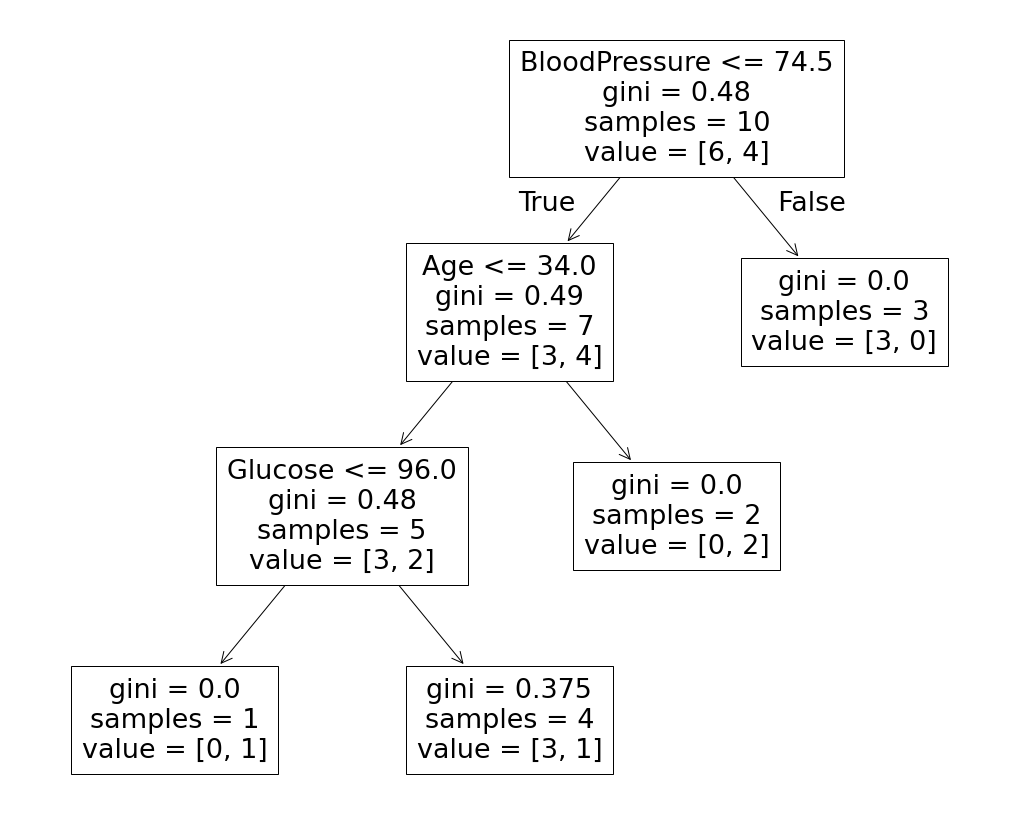

In [64]:
plt.figure(figsize=(18, 15))
plot_tree(decision_tree=dtc, feature_names=X.columns)
plt.show()

In [107]:
X.iloc[:1]

,Glucose,Age,BloodPressure
699,118,26,70


In [112]:
dtc.decision_path(X.iloc[:1])

<1x7 sparse matrix of type '<class 'numpy.int64'>'
	with 4 stored elements in Compressed Sparse Row format>

In [16]:
4/7 - 4/10

0.17142857142857137

In [117]:
a = [5*(0.48 - 4 / 5 * 0.375), 7*(0.49 - 5 / 7 * 0.48),  10*(0.48 - 0.7 * 0.49)]
a / np.sum(a)

array([0.27272727, 0.31212121, 0.41515152])

In [115]:
dtc.feature_importances_, dtc.feature_names_in_

(array([0.27272727, 0.31168831, 0.41558442]),
 array(['Glucose', 'Age', 'BloodPressure'], dtype=object))

In [130]:
(4 / 7 - 4 / 10) * (1/3)

0.05714285714285712